In [1]:
import sys
from pathlib import Path
from datetime import datetime, timezone
 
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
 
from scipy.ndimage import uniform_filter1d
from scipy.signal import detrend, butter, filtfilt
from scipy.integrate import cumulative_trapezoid
 
sys.path.append(r'/root/autodl-tmp')
from model import FaultCleanRule

In [2]:
H5_PATH    = r'/root/autodl-tmp/Test_on_Event/chichi/Chichi/Chichi.h5'
EVENT_DIR  = Path(r'/root/autodl-tmp/Test_on_Event/chichi/Chichi')
EVENT_NAME = 'chichi'
 
TRAIN_H5  = r'/root/autodl-tmp/data/data/events.h5'
CKPT_PATH = r'/root/autodl-tmp/checkpoints_pgv_aniso/pgv/best_iou_rule_hybrid.pth'
 
PICKS_CSV = EVENT_DIR / f'{EVENT_NAME}_picks.csv'
 
CHANNEL     = 'pgv'
GRID_SIZE   = 150
RESOLUTION  = 0.01
TOTAL_DUR   = 40.0
N_TIMESTEPS = 60
 
# 模型参数
MODEL_PATCH_SIZE            = 10
MODEL_D_MODEL               = 256
MODEL_N_LAYERS              = 6
MODEL_GRID_SIZE             = 150
MODEL_DECODER_DIM           = 32
MODEL_DECODER_MID_DIM       = 64
MODEL_DECODER_REFINE_BLOCKS = 3
MODEL_COMMIT_TAU            = 0.60
MODEL_COMMIT_TEMP           = 0.08
MODEL_CAUSAL                = True
 
# 物理截断
USE_PHYSICAL_END_TRUNCATION = True
FAULT_LENGTH_A              = 0.59
FAULT_LENGTH_B              = -2.44
RUPTURE_VELOCITY_KM_S       = 3.0
MIN_RUPTURE_DURATION_S      = 4.0
MAX_RUPTURE_DURATION_S      = 40.0
PHYSICAL_END_BUFFER_S       = 4.0
 
# 预处理
HP_HZ = 0.10; LP_HZ = 10.0; FILT_ORD = 4
 
# 推理参数
# Chi-Chi: CHN-TW 台网密集（~1000 台），sigma 与 KiKNet 相同
INTERP_SIGMA_DEG    = 0.15
INTERP_CUTOFF_SIGMA = 4.0
THRESHOLD           = 0.5
IGNORE_EARLY_SEC    = 0.0
VOTE_WINDOW         = 1
VOTE_THRESH         = 0.5
 
V_S_KM_S = 3.5

In [3]:
def parse_event_time(value):
    if value is None: return None
    text = value.decode('utf-8') if isinstance(value, (bytes, np.bytes_)) else str(value)
    text = text.strip().replace('Z', '+00:00')
    if not text: return None
    try:   dt = datetime.fromisoformat(text)
    except ValueError: return None
    return dt.replace(tzinfo=timezone.utc) if dt.tzinfo is None else dt
 
def magnitude_to_fault_length_km(mw):
    return float(10.0 ** (FAULT_LENGTH_A * float(mw) + FAULT_LENGTH_B))
 
def estimate_rupture_duration_s(mw, overrides=None, event_name=None):
    if overrides and event_name in overrides: return float(overrides[event_name])
    length_km = magnitude_to_fault_length_km(mw)
    return float(np.clip(length_km/RUPTURE_VELOCITY_KM_S,
                         MIN_RUPTURE_DURATION_S, MAX_RUPTURE_DURATION_S))
 
def truncate_after_time(arr, sr, end_in_record_s):
    arr = np.asarray(arr, dtype=np.float32).reshape(-1)
    idx = int(np.ceil(end_in_record_s * sr))
    if idx < len(arr):
        arr = arr.copy(); arr[idx:] = 0.0
    return arr
 
def estimate_t_first_trigger(dep_km, eq_lat, eq_lon, lons_sta, lats_sta, v_s=V_S_KM_S):
    if lons_sta is None or len(lons_sta) == 0: return dep_km / v_s
    dlat  = (lats_sta - eq_lat) * 111.0
    dlon  = (lons_sta - eq_lon) * 111.0 * np.cos(np.radians(eq_lat))
    dist3d = np.sqrt(dlat**2 + dlon**2 + dep_km**2)
    return float(dist3d.min() / v_s)
 
def gauss_interp(lons, lats, values, grid_lon, grid_lat,
                 sigma_deg=0.06, min_active=3, cutoff_sigma=None):
    H, W = grid_lon.shape
    field = np.zeros((H, W), dtype=np.float32)
    w_sum = np.zeros_like(field)
    active = [(lo, la, v) for lo, la, v in zip(lons, lats, values) if v > 0]
    if len(active) < min_active: return field
    for lo, la, val in active:
        dist2 = (grid_lon - lo)**2 + (grid_lat - la)**2
        w = np.exp(-dist2 / (2 * sigma_deg**2))
        if cutoff_sigma is not None:
            w *= (dist2 <= (cutoff_sigma * sigma_deg)**2).astype(np.float32)
        field += w * val; w_sum += w
    mask = w_sum > 1e-10; field[mask] /= w_sum[mask]
    return field.astype(np.float32)
 
def build_monotonic_station_pgv(stations, times, win_s=2.0):
    times = np.asarray(times, dtype=np.float32)
    out   = np.zeros((len(times), len(stations)), dtype=np.float32)
    for j, s in enumerate(stations):
        vel = np.asarray(s['waveform'], dtype=np.float32).reshape(-1)
        sr  = float(s['sr']); rec_offset = float(s.get('rec_offset_s', 0.0))
        if len(vel) == 0 or sr <= 0: continue
        abs_vel = np.abs(vel); win_n = max(1, int(round(win_s * sr))); cur_max = 0.0
        for k, t_abs in enumerate(times):
            t_rec = float(t_abs) - rec_offset
            if t_rec <= 0: out[k, j] = cur_max; continue
            i1 = int(np.clip(np.ceil(t_rec * sr), 0, len(abs_vel)))
            if i1 <= 0: out[k, j] = cur_max; continue
            i0 = max(0, i1 - win_n)
            loc_max = float(abs_vel[i0:i1].max()) if i1 > i0 else 0.0
            cur_max = max(cur_max, loc_max); out[k, j] = cur_max
    return out
 
def sliding_window_vote(pred_binary, win=5, thresh=0.5):
    x = np.asarray(pred_binary, dtype=np.float32)
    if win <= 1: return (x > 0.5).astype(np.uint8)
    avg = uniform_filter1d(x, size=win, axis=0, mode='nearest')
    return (avg >= thresh).astype(np.uint8)

In [4]:
def preprocess_acc_to_vel(acc, sr, hp=HP_HZ, lp=LP_HZ, order=FILT_ORD):
    """与 KiKNet real_event.ipynb 中 preprocess_acc_to_vel 完全一致"""
    x = np.asarray(acc, dtype=np.float64)
    n_pre = max(1, min(20, len(x) // 10))
    x -= np.median(x[:n_pre])
    x = detrend(x, type='linear')
    nyq = sr / 2.0
    b, a = butter(order, [max(hp/nyq, 1e-5), min(lp/nyq, 0.999)], btype='band')
    x = filtfilt(b, a, x)
    v = cumulative_trapezoid(x, dx=1.0/sr, initial=0.0)
    v = detrend(v, type='linear')
    b2, a2 = butter(2, max(0.05/nyq, 1e-5), btype='high')
    v = filtfilt(b2, a2, v)
    return v.astype(np.float32)
 
def pick_waveform_tw(wgrp, sr):
    """
    CHN-TW 通道优先级：EW → NS → V
    返回 (vel, channel_note)，vel 已做 acc→vel 转换。
    """
    for key in ('EW', 'NS', 'V'):
        if key in wgrp:
            acc = np.asarray(wgrp[key][:], dtype=np.float32).reshape(-1)
            if acc.size > 0:
                vel = preprocess_acc_to_vel(acc, sr)
                return vel, key
    return None, None
 
def load_picks(csv_path):
    p = Path(csv_path)
    if not p.exists():
        print(f'  [WARNING] picks CSV not found: {p}'); return {}
    df = pd.read_csv(p, index_col='station_id')
    picks = {sid: (None if pd.isna(row['p_pick_s']) else float(row['p_pick_s']))
             for sid, row in df.iterrows()}
    print(f'  Loaded picks: {sum(v is not None for v in picks.values())}/{len(picks)}')
    return picks

In [5]:
with h5py.File(TRAIN_H5, 'r') as f:
    ng = f['normalization_diff']
    if CHANNEL == 'pgv':
        DIFF_MEAN = float(ng.attrs['dpgv_mean']); DIFF_STD = float(ng.attrs['dpgv_std'])
    elif CHANNEL == 'pga':
        DIFF_MEAN = float(ng.attrs['dpga_mean']); DIFF_STD = float(ng.attrs['dpga_std'])
    else:
        DIFF_MEAN = float(ng.attrs['dint_mean']);  DIFF_STD = float(ng.attrs['dint_std'])
print(f'Norm: DIFF_MEAN={DIFF_MEAN:.4f}  DIFF_STD={DIFF_STD:.4f}')
 
# %%
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
ckpt      = torch.load(CKPT_PATH, map_location=device)
ckpt_args = ckpt.get('args', {}) if isinstance(ckpt, dict) else {}
def _arg(k, d): return ckpt_args.get(k, d) if isinstance(ckpt_args, dict) else d
 
model = FaultCleanRule(
    in_channels=1,
    patch_size              = int(_arg('patch_size',            MODEL_PATCH_SIZE)),
    d_model                 = int(_arg('d_model',               MODEL_D_MODEL)),
    n_layers                = int(_arg('n_layers',              MODEL_N_LAYERS)),
    grid_size               = int(_arg('grid_size',             MODEL_GRID_SIZE)),
    decoder_dim             = int(_arg('decoder_dim',           MODEL_DECODER_DIM)),
    decoder_mid_dim         = int(_arg('decoder_mid_dim',       MODEL_DECODER_MID_DIM)),
    decoder_refine_blocks   = int(_arg('decoder_refine_blocks', MODEL_DECODER_REFINE_BLOCKS)),
    causal                  = bool(_arg('causal',               MODEL_CAUSAL)),
    commit_tau              = float(_arg('commit_tau',          MODEL_COMMIT_TAU)),
    commit_temp             = float(_arg('commit_temp',         MODEL_COMMIT_TEMP)),
).to(device)
 
state = ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt
if all(k.startswith('module.') for k in state.keys()):
    state = {k.replace('module.','',1): v for k, v in state.items()}
model.load_state_dict(state, strict=True); model.eval()
print('Model loaded.')

Norm: DIFF_MEAN=1.0448  DIFF_STD=3.4739
Device: cuda
Model loaded.


In [6]:
def run_chichi_event(event_dir, h5_path, picks_csv,
                     model, device, diff_mean, diff_std,
                     rupture_duration_overrides=None,
                     effective_end_overrides=None):
 
    event_dir = Path(event_dir); name = event_dir.name
    picks = load_picks(picks_csv)
 
    with h5py.File(h5_path, 'r') as f:
        eq      = f['earthquake']
        EQ_MAG  = float(eq.attrs['magnitude'])
        EQ_DEP  = float(eq.attrs['depth'])
        EQ_LAT  = float(eq.attrs['latitude'])
        EQ_LON  = float(eq.attrs['longitude'])
        eq_origin = parse_event_time(eq.attrs.get('origin_time'))
 
        rupture_dur = estimate_rupture_duration_s(
            EQ_MAG, overrides=rupture_duration_overrides, event_name=name)
        eff_end = (effective_end_overrides.get(name, rupture_dur + PHYSICAL_END_BUFFER_S)
                   if effective_end_overrides else rupture_dur + PHYSICAL_END_BUFFER_S)
 
        stations = []
        for sta_id, g in f['stations'].items():
            if 'waveforms' not in g: continue
 
            lon = float(g.attrs.get('longitude', 0.0))
            lat = float(g.attrs.get('latitude',  0.0))
            sr  = float(g.attrs.get('sampling_rate', 250.0))
 
            # ── CHN-TW: acc → vel，通道优先级 EW > NS > V ──────────────────
            vel, ch_note = pick_waveform_tw(g['waveforms'], sr)
            if vel is None or len(vel) == 0: continue
 
            # ── 时间对齐 ─────────────────────────────────────────────────────
            # CHN-TW: record_time = EQTimeStp - PreEventTime（已由 CHNTWToHDF5 写入）
            # rec_offset_s = -PreEventTime（固定负值，e.g. -11s）
            rec_start    = parse_event_time(g.attrs.get('record_time'))
            if rec_start is None: rec_start = eq_origin
            rec_offset_s = (rec_start - eq_origin).total_seconds()
 
            # ── P 波拾取 ─────────────────────────────────────────────────────
            p_pick_abs = picks.get(sta_id)
            t_in_rec   = (float(p_pick_abs) - rec_offset_s
                          if p_pick_abs is not None else np.inf)
 
            # ── 物理截断 ─────────────────────────────────────────────────────
            end_in_record_s  = eff_end - rec_offset_s
            waveform_for_pgv = (truncate_after_time(vel, sr, end_in_record_s)
                                if USE_PHYSICAL_END_TRUNCATION else vel.copy())
 
            stations.append({
                'name':          sta_id,
                'lon':           lon,
                'lat':           lat,
                'sr':            sr,
                't_offset':      t_in_rec if np.isfinite(t_in_rec) else np.inf,
                'rec_offset_s':  rec_offset_s,
                'waveform':      waveform_for_pgv,   # abs(vel) cm/s
                'channel':       ch_note,
            })
 
    # ── 网格范围 & 台站筛选 ───────────────────────────────────────────────────
    half    = GRID_SIZE * RESOLUTION * 0.5    # = 0.75°
    lon_min = EQ_LON - half; lon_max = EQ_LON + half
    lat_min = EQ_LAT - half; lat_max = EQ_LAT + half
 
    stations = [s for s in stations
                if lon_min <= s['lon'] <= lon_max and lat_min <= s['lat'] <= lat_max]
    print(f'  Stations in grid: {len(stations)}')
    if len(stations) == 0:
        print('  [FAILED] No stations in grid.'); return None
 
    lons_sta = np.array([s['lon'] for s in stations], dtype=np.float32)
    lats_sta = np.array([s['lat'] for s in stations], dtype=np.float32)
 
    t_first_trigger_s = estimate_t_first_trigger(EQ_DEP, EQ_LAT, EQ_LON, lons_sta, lats_sta)
    times_abs = np.linspace(0.0, TOTAL_DUR, N_TIMESTEPS, dtype=np.float32)
 
    # ── PGV 场构建 ────────────────────────────────────────────────────────────
    station_pgv_cum = build_monotonic_station_pgv(stations, times_abs)
 
    grid_lons = np.linspace(lon_min, lon_max, GRID_SIZE, dtype=np.float32)
    grid_lats = np.linspace(lat_min, lat_max, GRID_SIZE, dtype=np.float32)
    grid_lon, grid_lat = np.meshgrid(grid_lons, grid_lats)
 
    pgv_fields = np.stack([
        gauss_interp(lons_sta, lats_sta, station_pgv_cum[k],
                     grid_lon, grid_lat,
                     sigma_deg=INTERP_SIGMA_DEG,
                     cutoff_sigma=INTERP_CUTOFF_SIGMA)
        for k in range(N_TIMESTEPS)
    ], axis=0)
 
    dpgv = np.maximum(np.diff(pgv_fields, axis=0, prepend=pgv_fields[:1]), 0.0)
 
    valid_mask = times_abs >= (t_first_trigger_s + IGNORE_EARLY_SEC)
    valid_idx  = np.where(valid_mask)[0]
    if len(valid_idx) == 0:
        print('  [FAILED] No valid frames.'); return None
 
    # ── 归一化 & 推理 ─────────────────────────────────────────────────────────
    dpgv_norm   = (dpgv[valid_idx] - diff_mean) / (diff_std + 1e-8)
    inputs_t    = torch.from_numpy(dpgv_norm[np.newaxis, np.newaxis]).float().to(device)
    times_mid   = times_abs[valid_idx].astype(np.float32)
    times_t     = torch.from_numpy(times_mid[np.newaxis]).float().to(device)
    seq_mask    = torch.ones(1, len(valid_idx), dtype=torch.bool, device=device)
    epi_x = (EQ_LON - lon_min) / (lon_max - lon_min)
    epi_y = (EQ_LAT - lat_min) / (lat_max - lat_min)
    epicenter_t = torch.tensor([[epi_x, epi_y]], dtype=torch.float32, device=device)
 
    with torch.no_grad():
        belief_logits, committeds = model(inputs_t, times_t, seq_mask, epicenter_t)
 
    committed_prob = committeds[0].cpu().numpy()
    pred_binary    = (committed_prob > THRESHOLD).astype(np.uint8)
    pred_sliding   = sliding_window_vote(committed_prob, win=VOTE_WINDOW, thresh=VOTE_THRESH)
 
    # ── 保存 ──────────────────────────────────────────────────────────────────
    event_dir.mkdir(parents=True, exist_ok=True)
    np.save(event_dir / 'pred_binary.npy',      pred_binary)
    np.save(event_dir / 'pred_prob.npy',         committed_prob)
    np.save(event_dir / 'pred_sliding_vote.npy', pred_sliding)
    np.save(event_dir / 'times_mid_valid.npy',   times_mid)
    np.save(event_dir / 'pgv_fields.npy',        pgv_fields)
    np.savez(event_dir / 'event_metadata.npz',
             eq_lat=np.float32(EQ_LAT), eq_lon=np.float32(EQ_LON),
             eq_mag=np.float32(EQ_MAG), eq_dep=np.float32(EQ_DEP),
             lon_min=np.float32(lon_min), lon_max=np.float32(lon_max),
             lat_min=np.float32(lat_min), lat_max=np.float32(lat_max),
             t_first_trigger_s=np.float32(t_first_trigger_s),
             effective_end_abs_s=np.float32(eff_end))
    print(f'  Saved to {event_dir}')
 
    # ── 快速预览 ──────────────────────────────────────────────────────────────
    preview_frames = np.where(times_mid <= eff_end)[0]
    last_show = int(np.clip(
        preview_frames[-1] if len(preview_frames) > 0 else len(valid_idx)-1,
        0, len(valid_idx)-1))
    n_show   = min(10, committed_prob.shape[0])
    show_idx = np.linspace(0, last_show, n_show, dtype=int)
 
    fig, axes = plt.subplots(2, n_show, figsize=(3*n_show, 6))
    for col, fi in enumerate(show_idx):
        axes[0, col].imshow(committed_prob[fi], vmin=0, vmax=1, cmap='hot', origin='lower')
        axes[0, col].set_title(f't={times_mid[fi]:.1f}s', fontsize=7)
        axes[0, col].axis('off')
        axes[1, col].imshow(pred_binary[fi], vmin=0, vmax=1, cmap='gray', origin='lower')
        axes[1, col].axis('off')
    axes[0, 0].set_ylabel('prob', fontsize=8); axes[1, 0].set_ylabel('binary', fontsize=8)
    fig.suptitle(f'{name}  |  Mw{EQ_MAG}  |  {len(stations)} stations  '
                 f'|  t_first={t_first_trigger_s:.1f}s  eff_end={eff_end:.1f}s', fontsize=9)
    plt.tight_layout()
    plt.savefig(event_dir / 'preview.png', dpi=120, bbox_inches='tight')
    plt.show()
    return pred_binary


Processing: chichi
  [WARNING] picks CSV not found: /root/autodl-tmp/Test_on_Event/chichi/Chichi/chichi_picks.csv
  Stations in grid: 71
  Saved to /root/autodl-tmp/Test_on_Event/chichi/Chichi


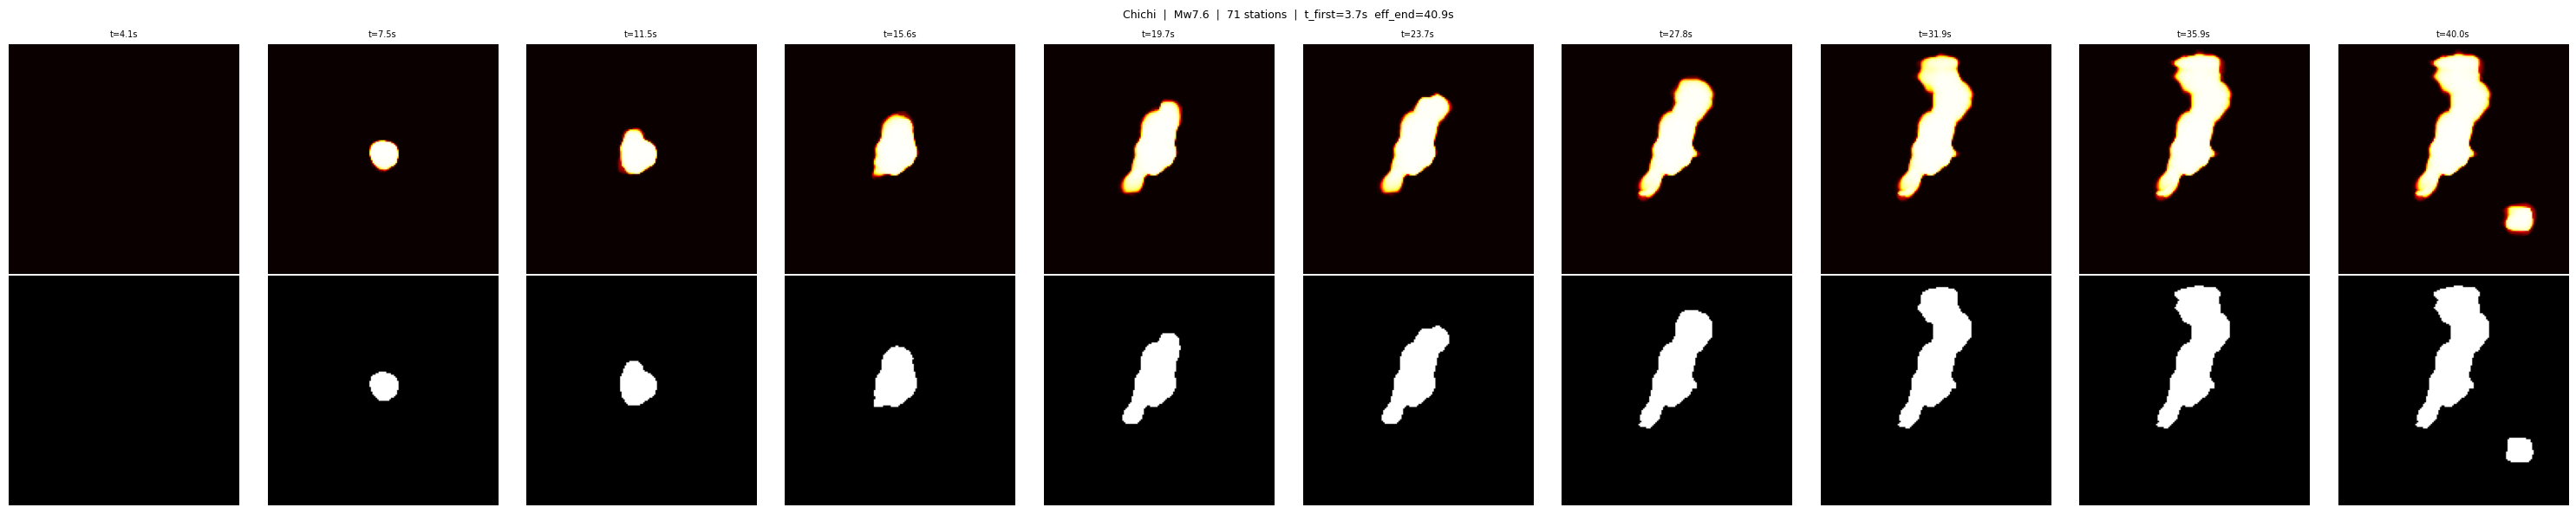

Done. pred_binary shape: (54, 150, 150)


In [7]:
print(f'\nProcessing: {EVENT_NAME}')
pred = run_chichi_event(
    event_dir = EVENT_DIR,
    h5_path   = H5_PATH,
    picks_csv = PICKS_CSV,
    model     = model,
    device    = device,
    diff_mean = DIFF_MEAN,
    diff_std  = DIFF_STD,
)
if pred is not None:
    print(f'Done. pred_binary shape: {pred.shape}')
else:
    print('[FAILED]')
 